# Europarl EN to FR - LSTM + Attention Training

- `MAX_LINES=200_000`, length filter `1-50` words, length-ratio filter `[0.5, 2.0]`, 
- Shuffled split with seed 42 into 174k/3k/3k train/val/test.
- SentencePiece BPE tokenizer (16k joint EN+FR vocab)

In [21]:
!pip install -q sentencepiece sacrebleu

In [22]:
import os, math, random, time, json, shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm
import sacrebleu
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


In [23]:
DRIVE_BASE_DIR = '/content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets'
DRIVE_DIR = os.path.join(DRIVE_BASE_DIR, 'm_training_lstm')
RUN_ID = 'lstm'
DRIVE_OK = False
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    os.makedirs(DRIVE_DIR, exist_ok=True)
    DRIVE_OK = True
    print(f"Drive mounted. Artifacts will be persisted to:\n  {DRIVE_DIR}")
except Exception as e:
    print(f"Drive not available ({type(e).__name__}: {e})")
    print("Continuing with local-only saves.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Artifacts will be persisted to:
  /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_lstm


In [24]:
# Download Europarl.
print("Downloading Europarl EN-FR")
!wget -q -O europarl.zip https://object.pouta.csc.fi/OPUS-Europarl/v7/moses/en-fr.txt.zip
!unzip -q -o europarl.zip
!ls -la Europarl.en-fr.* 2>/dev/null
print("Done")

-rw-rw-r-- 1 root root 308075245 Dec  5  2014 Europarl.en-fr.en
-rw-rw-r-- 1 root root 354082884 Dec  5  2014 Europarl.en-fr.fr
-rw-rw-r-- 1 root root 114158575 Dec  5  2014 Europarl.en-fr.ids
Done


In [25]:
# Train/val/test splits 
MAX_LINES = 200000
MIN_TOK, MAX_TOK = 1, 50

pairs = []
with open('Europarl.en-fr.en', 'r', encoding='utf-8') as fe, \
     open('Europarl.en-fr.fr', 'r', encoding='utf-8') as ff:
    for i, (e, f) in enumerate(zip(fe, ff)):
        if i >= MAX_LINES:
            break
        e = e.strip().lower()
        f = f.strip().lower()
        if not e or not f:
            continue
        ne, nf = len(e.split()), len(f.split())
        if not (MIN_TOK <= ne <= MAX_TOK and MIN_TOK <= nf <= MAX_TOK):
            continue
        if not (0.5 <= ne / nf <= 2.0):
            continue
        pairs.append((e, f))

print(f"Aligned pairs after filtering: {len(pairs):,}")

Aligned pairs after filtering: 180,289


In [26]:
rng = random.Random(42)
rng.shuffle(pairs)

n_val, n_test = 3000, 3000
n_train = len(pairs) - n_val - n_test
train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train + n_val]
test_pairs  = pairs[n_train + n_val:]

print(f"Train: {len(train_pairs):,} | Val: {len(val_pairs):,} | Test: {len(test_pairs):,}")

Path('data').mkdir(exist_ok=True)
for name, data in [('train', train_pairs), ('val', val_pairs), ('test', test_pairs)]:
    with open(f'data/{name}.en', 'w') as fe, open(f'data/{name}.fr', 'w') as ff:
        for e, f in data:
            fe.write(e + '\n')
            ff.write(f + '\n')

with open('data/spm_train.txt', 'w') as fo:
    for e, f in train_pairs:
        fo.write(e + '\n')
        fo.write(f + '\n')
print("Wrote data/{train,val,test}.{en,fr} and data/spm_train.txt")

Train: 174,289 | Val: 3,000 | Test: 3,000
Wrote data/{train,val,test}.{en,fr} and data/spm_train.txt


In [27]:
VOCAB_SIZE = 16000
if not os.path.exists('spm.model'):
    spm.SentencePieceTrainer.train(
        input='data/spm_train.txt',
        model_prefix='spm',
        vocab_size=VOCAB_SIZE,
        model_type='bpe',
        pad_id=0, unk_id=1, bos_id=2, eos_id=3,
        pad_piece='<pad>', unk_piece='<unk>', bos_piece='<s>', eos_piece='</s>',
        character_coverage=1.0,
        num_threads=os.cpu_count(),
    )
else:
    print("spm.model already present — skipping BPE training.")

sp = spm.SentencePieceProcessor()
sp.load('spm.model')
print(f"Vocab size: {sp.get_piece_size()}")

PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3

Vocab size: 16000


In [28]:
MAX_LEN = 64  # in BPE units

class TranslationDataset(Dataset):
    def __init__(self, pairs, sp, max_len=MAX_LEN):
        self.pairs = pairs; self.sp = sp; self.max_len = max_len
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        e, f = self.pairs[idx]
        src = self.sp.encode(e, out_type=int)[:self.max_len - 2]
        tgt = self.sp.encode(f, out_type=int)[:self.max_len - 2]
        return (torch.tensor([BOS_ID] + src + [EOS_ID], dtype=torch.long),
                torch.tensor([BOS_ID] + tgt + [EOS_ID], dtype=torch.long))

def collate(batch):
    srcs, tgts = zip(*batch)
    max_s = max(len(s) for s in srcs); max_t = max(len(t) for t in tgts)
    src_pad = torch.full((len(batch), max_s), PAD_ID, dtype=torch.long)
    tgt_pad = torch.full((len(batch), max_t), PAD_ID, dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, tgts)):
        src_pad[i, :len(s)] = s; tgt_pad[i, :len(t)] = t
    return src_pad, tgt_pad

BATCH_SIZE = 64
train_loader = DataLoader(TranslationDataset(train_pairs, sp), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, collate_fn=collate, pin_memory=True, drop_last=True)
val_loader   = DataLoader(TranslationDataset(val_pairs, sp), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=collate, pin_memory=True)
test_loader  = DataLoader(TranslationDataset(test_pairs, sp), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, collate_fn=collate, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 2723 | Val: 47 | Test: 47


In [29]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.hidden_dim = hidden_dim; self.num_layers = num_layers
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, (hidden, cell) = self.lstm(embedded)
        hidden = hidden.view(self.num_layers, 2, -1, self.hidden_dim)
        hidden = hidden.permute(1, 0, 2, 3).contiguous()
        hidden = hidden.view(2, -1, self.hidden_dim * 2)
        cell = cell.view(self.num_layers, 2, -1, self.hidden_dim)
        cell = cell.permute(1, 0, 2, 3).contiguous()
        cell = cell.view(2, -1, self.hidden_dim * 2)
        return outputs, hidden, cell

class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim * 2, num_layers,
                            batch_first=True, dropout=dropout)
        self.attention = nn.Linear(hidden_dim * 4, 1)
        self.fc_out = nn.Linear(hidden_dim * 4, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.hidden_dim = hidden_dim
    def forward(self, x, hidden, cell, encoder_outputs):
        if x.dim() == 1:
            x = x.unsqueeze(1)
        embedded = self.dropout(self.embedding(x))
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        seq_len = encoder_outputs.shape[1]
        hidden_repeated = hidden[-1].unsqueeze(1).repeat(1, seq_len, 1)
        concat = torch.cat((hidden_repeated, encoder_outputs), dim=2)
        attention_weights = torch.softmax(self.attention(concat), dim=1)
        context = torch.sum(attention_weights * encoder_outputs, dim=1).unsqueeze(1)
        concat_final = torch.cat((output, context), dim=2)
        prediction = self.fc_out(concat_final)
        return prediction.squeeze(1), hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder; self.decoder = decoder; self.device = device
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        trg_len = trg.shape[1]; batch_size = trg.shape[0]
        trg_vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        encoder_outputs, hidden, cell = self.encoder(src)
        input = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[:, t] if teacher_force else top1
        return outputs

vocab_size = sp.get_piece_size()
embedding_dim = 128
hidden_dim = 256
dropout = 0.3
num_layers = 2

encoder = Encoder(vocab_size, embedding_dim, hidden_dim, num_layers, dropout)
decoder = Decoder(vocab_size, embedding_dim, hidden_dim, num_layers, dropout)
model = Seq2Seq(encoder, decoder, device).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params/1e6:.1f}M")
print(f"  embedding_dim={embedding_dim}, hidden_dim={hidden_dim}, num_layers={num_layers}, dropout={dropout}")

Model parameters: 26.3M
  embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.3


In [30]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Optimizer: Adam (lr=0.001, wd=1e-5)")
print("Loss: CrossEntropyLoss (ignore PAD)")
print("Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

Optimizer: Adam (lr=0.001, wd=1e-5)
Loss: CrossEntropyLoss (ignore PAD)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


In [31]:
EPOCHS = 35
GRAD_CLIP = 1.0
EARLY_STOP_PATIENCE = 7
PRINT_EVERY = 200

def run_epoch(loader, train: bool, teacher_ratio=0.0):
    model.train(train)
    total_loss, total_batches = 0.0, 0
    t0 = time.time()
    for i, (src, tgt) in enumerate(loader):
        src = src.to(device, non_blocking=True); tgt = tgt.to(device, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)
        output = model(src, tgt, teacher_forcing_ratio=teacher_ratio if train else 0.0)
        loss = criterion(output[:, 1:, :].reshape(-1, output.shape[-1]), tgt[:, 1:].reshape(-1))
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        total_loss += loss.item(); total_batches += 1
        if train and (i % PRINT_EVERY == 0):
            cur_lr = optimizer.param_groups[0]['lr']
            print(f"  step {i:5d}/{len(loader)} | loss {loss.item():.3f} | lr {cur_lr:.2e}")
    return total_loss / max(total_batches, 1), time.time() - t0

best_val = float('inf')
best_epoch = 0
patience_counter = 0
train_curve, val_curve, epoch_times = [], [], []

for epoch in range(1, EPOCHS + 1):
    teacher_ratio = max(0.3, 0.9 - (epoch - 1) * 0.02)
    print(f"\nEpoch {epoch}/{EPOCHS}  (teacher forcing: {teacher_ratio:.2f})")

    tr_loss, tr_t = run_epoch(train_loader, train=True, teacher_ratio=teacher_ratio)
    va_loss, va_t = run_epoch(val_loader, train=False)
    train_curve.append(tr_loss); val_curve.append(va_loss); epoch_times.append(tr_t + va_t)

    scheduler.step(va_loss)
    cur_lr = optimizer.param_groups[0]['lr']
    print(f"  Train loss {tr_loss:.4f} ({tr_t:5.0f}s)  |  Val loss {va_loss:.4f} ({va_t:5.0f}s)  |  lr {cur_lr:.2e}")

    if va_loss < best_val:
        best_val = va_loss; best_epoch = epoch; patience_counter = 0
        ckpt = {
            'Model': model.state_dict(), 'epoch': epoch, 'val_loss': va_loss, 'run_id': RUN_ID,
            'config': {'embedding_dim': embedding_dim, 'hidden_dim': hidden_dim,
                       'num_layers': num_layers, 'dropout': dropout,
                       'vocab_size': vocab_size, 'max_len': MAX_LEN},
        }
        torch.save(ckpt, 'best.pt')
        if DRIVE_OK:
            try:
                torch.save(ckpt, os.path.join(DRIVE_DIR, 'best.pt'))
                print(f"  Saved best.pt locally + to Drive (val loss {va_loss:.4f})")
            except Exception as e:
                print(f"  Saved best.pt locally; Drive save FAILED ({type(e).__name__}: {e})")
        else:
            print(f"  Saved best.pt locally only (val loss {va_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience {patience_counter}/{EARLY_STOP_PATIENCE}")
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print(f"\nBest val loss: {best_val:.4f}  (perplexity {math.exp(best_val):.2f}) at epoch {best_epoch}")


Epoch 1/35  (teacher forcing: 0.90)
  step     0/2723 | loss 9.682 | lr 1.00e-03
  step   200/2723 | loss 5.886 | lr 1.00e-03
  step   400/2723 | loss 5.190 | lr 1.00e-03
  step   600/2723 | loss 5.286 | lr 1.00e-03
  step   800/2723 | loss 4.847 | lr 1.00e-03
  step  1000/2723 | loss 4.877 | lr 1.00e-03
  step  1200/2723 | loss 4.530 | lr 1.00e-03
  step  1400/2723 | loss 4.275 | lr 1.00e-03
  step  1600/2723 | loss 4.244 | lr 1.00e-03
  step  1800/2723 | loss 4.262 | lr 1.00e-03
  step  2000/2723 | loss 4.324 | lr 1.00e-03
  step  2200/2723 | loss 4.058 | lr 1.00e-03
  step  2400/2723 | loss 4.132 | lr 1.00e-03
  step  2600/2723 | loss 4.003 | lr 1.00e-03
  Train loss 4.6500 (  461s)  |  Val loss 7.2971 (    3s)  |  lr 1.00e-03
  Saved best.pt locally + to Drive (val loss 7.2971)

Epoch 2/35  (teacher forcing: 0.88)
  step     0/2723 | loss 4.021 | lr 1.00e-03
  step   200/2723 | loss 4.115 | lr 1.00e-03
  step   400/2723 | loss 3.875 | lr 1.00e-03
  step   600/2723 | loss 4.146 | l

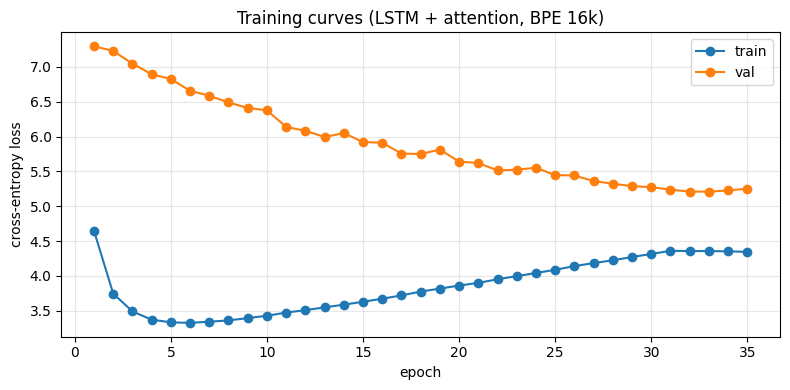

Copied curves.png → /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_lstm


In [32]:
plt.figure(figsize=(8, 4))
xs = list(range(1, len(train_curve) + 1))
plt.plot(xs, train_curve, marker='o', label='train')
plt.plot(xs, val_curve, marker='o', label='val')
plt.xlabel('epoch'); plt.ylabel('cross-entropy loss')
plt.title('Training curves (LSTM + attention, BPE 16k)')
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.savefig('curves.png', dpi=120, bbox_inches='tight')
plt.show()

if DRIVE_OK:
    try:
        shutil.copy('curves.png', os.path.join(DRIVE_DIR, 'curves.png'))
        print(f"Copied curves.png → {DRIVE_DIR}")
    except Exception as e:
        print(f"Could not copy curves.png to Drive ({type(e).__name__}: {e})")

In [33]:
# Save the SentencePiece tokenizer alongside best.pt on Drive.
if DRIVE_OK:
    for f in ['spm.model', 'spm.vocab']:
        if os.path.exists(f):
            try:
                shutil.copy(f, os.path.join(DRIVE_DIR, f))
                print(f"Copied {f} → {DRIVE_DIR}")
            except Exception as e:
                print(f"Could not copy {f} ({type(e).__name__}: {e})")
else:
    print("Drive not mounted; skipping tokenizer persistence.")

Copied spm.model → /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_lstm
Copied spm.vocab → /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_lstm


In [34]:
ckpt = torch.load('best.pt', map_location=device)
model.load_state_dict(ckpt['Model'])
model.eval()
print(f"Loaded best.pt (epoch {ckpt['epoch']}, val loss {ckpt['val_loss']:.4f})")

@torch.no_grad()
def greedy_decode_batch(src, max_len=80):
    model.eval()
    encoder_outputs, hidden, cell = model.encoder(src)
    B = src.size(0)
    cur = torch.full((B,), BOS_ID, dtype=torch.long, device=device)
    out_seqs = [[] for _ in range(B)]
    finished = torch.zeros(B, dtype=torch.bool, device=device)
    for _ in range(max_len):
        output, hidden, cell = model.decoder(cur, hidden, cell, encoder_outputs)
        nxt = output.argmax(-1)
        for b in range(B):
            if not finished[b].item():
                tok = int(nxt[b])
                if tok == EOS_ID:
                    finished[b] = True
                else:
                    out_seqs[b].append(tok)
        cur = nxt
        if finished.all():
            break
    return out_seqs

def ids_to_text(ids):
    out = []
    for i in ids:
        i = int(i)
        if i in (BOS_ID, PAD_ID): continue
        if i == EOS_ID: break
        out.append(i)
    return sp.decode(out)

@torch.no_grad()
def corpus_bleu(loader, name):
    refs, hyps = [], []
    for src, tgt in loader:
        src = src.to(device)
        out = greedy_decode_batch(src, max_len=80)
        for i in range(src.size(0)):
            refs.append(ids_to_text(tgt[i].tolist()))
            hyps.append(sp.decode(out[i]))
    bleu = sacrebleu.corpus_bleu(hyps, [refs])
    print(f"[{name}] BLEU = {bleu.score:.2f}  (n={len(hyps)})")
    return bleu.score, hyps, refs

val_bleu,  val_hyps,  val_refs  = corpus_bleu(val_loader,  'val')
test_bleu, test_hyps, test_refs = corpus_bleu(test_loader, 'test')

Loaded best.pt (epoch 32, val loss 5.2104)
[val] BLEU = 6.67  (n=3000)
[test] BLEU = 6.59  (n=3000)


In [35]:
@torch.no_grad()
def beam_search(text, beam=5, max_len=80, len_penalty=0.6):
    model.eval()
    src_ids = [BOS_ID] + sp.encode(text.lower(), out_type=int)[:MAX_LEN - 2] + [EOS_ID]
    src = torch.tensor([src_ids], device=device)
    encoder_outputs, hidden, cell = model.encoder(src)
    encoder_outputs_b = encoder_outputs.expand(beam, -1, -1).contiguous()
    hidden_b = hidden.expand(-1, beam, -1).contiguous()
    cell_b   = cell.expand(-1, beam, -1).contiguous()
    seqs = torch.full((beam, 1), BOS_ID, dtype=torch.long, device=device)
    scores = torch.full((beam,), -1e9, device=device); scores[0] = 0.0
    finished = []
    cur = seqs[:, -1]
    for _ in range(max_len - 1):
        output, hidden_b, cell_b = model.decoder(cur, hidden_b, cell_b, encoder_outputs_b)
        logp = F.log_softmax(output, dim=-1)
        cand = scores.unsqueeze(1) + logp
        topk = cand.view(-1).topk(beam)
        beam_idx = topk.indices // vocab_size
        tok_idx  = topk.indices %  vocab_size
        hidden_b = hidden_b[:, beam_idx, :].contiguous()
        cell_b   = cell_b[:, beam_idx, :].contiguous()
        seqs = torch.cat([seqs[beam_idx], tok_idx.unsqueeze(1)], dim=1)
        scores = topk.values
        is_eos = (tok_idx == EOS_ID)
        for b in is_eos.nonzero(as_tuple=True)[0].tolist():
            lp = ((5 + seqs.size(1)) / 6.0) ** len_penalty
            finished.append((scores[b].item() / lp, seqs[b].tolist()))
            scores[b] = -1e9
        if len(finished) >= beam:
            break
        cur = tok_idx
    if not finished:
        b = int(scores.argmax())
        finished.append((scores[b].item(), seqs[b].tolist()))
    finished.sort(key=lambda x: -x[0])
    return ids_to_text(finished[0][1])

samples = [
    "resumption of the session",
    "thank you for your attention",
    "i agree with the proposal",
    "climate change is a serious problem",
    "the european parliament meets today",
    "we must protect human rights and democratic values",
    "the commission has presented a new directive on energy efficiency",
]
print("Beam search (beam=5):\n")
for s in samples:
    print(f"  EN: {s}")
    print(f"  FR: {beam_search(s, beam=5)}")
    print()

Beam search (beam=5):

  EN: resumption of the session
  FR: la reprise de la session de session de la session de session de

  EN: thank you for your attention
  FR: je remercie remercie pour votre attention pour votre attention pour votre attention sur votre attention sur votre attention.

  EN: i agree with the proposal
  FR: je suis d'accord avec la proposition de la proposition de la proposition de la proposition de

  EN: climate change is a serious problem
  FR: le changement climatique est un changement climatique est un climat climatique et

  EN: the european parliament meets today
  FR: aujourd'hui, le parlement européen parlement européen parlement européen parlement européen parlement européen

  EN: we must protect human rights and democratic values
  FR: nous devons protéger protéger les valeurs démocratiques droits de l'homme et protéger les valeurs démocratiques

  EN: the commission has presented a new directive on energy efficiency
  FR: la commission a présenté une 

In [36]:
print(f"Final BLEU — val: {val_bleu:.2f}, test: {test_bleu:.2f}\n")
for i in range(8):
    print(f"Example {i}")
    print(f"REF: {test_refs[i]}")
    print(f"HYP: {test_hyps[i]}")
    print()

Final BLEU — val: 6.67, test: 6.59

Example 0
REF: le sommet de lisbonne, chers collègues, était un peu le point de départ d'une longue histoire et nous ne sommes qu'au début de cette longue histoire.
HYP: nous avons début de lisbonne, nous le départ de départ de lisbonne.

Example 1
REF: ces chiffres cachent non seulement une souffrance personnelle incommensurable, mais ils impliquent aussi d' énormes pertes économiques, et donc d' énormes coûts.
HYP: ces chiffres sont considérables, ces pertes ne sont pas seulement considérables, mais aussi, les pertes économiques.

Example 2
REF: dire que nous avons besoin d'une constitution ne signifie pas que l'union européenne devrait avoir la constitution d'un état, car l'union n'est pas un état et n'est pas prête de le devenir.
HYP: nous ne dire que' état membre ne constitution pas pas' état état membre,'' constitution' état membre,'' constitution' état membre.

Example 3
REF: back to basics doit être la règle de conduite.
HYP: nous devons reve

### Analytics & Backup

In [37]:
# Defines save_run_artifacts (writes metrics.json + predictions.csv) and the loaders used by all analytics cells.
def save_run_artifacts(run_id, drive_path, drive_ok, *,
                       arch, config, n_pairs, best_epoch, best_val_loss,
                       train_curve, val_curve, epoch_times,
                       val_bleu, test_bleu,
                       val_pairs, val_refs, val_hyps,
                       test_pairs, test_refs, test_hyps):
    metrics = {
        'run_id': run_id, 'arch': arch, 'config': config, 'n_pairs': n_pairs,
        'best_epoch': best_epoch, 'best_val_loss': float(best_val_loss),
        'val_bleu': float(val_bleu), 'test_bleu': float(test_bleu),
        'train_curve': [float(x) for x in train_curve],
        'val_curve':   [float(x) for x in val_curve],
        'epoch_times_s': [float(x) for x in epoch_times],
        'timestamp': datetime.now().isoformat(timespec='seconds'),
    }
    local_metrics = f'metrics_{run_id}.json'
    with open(local_metrics, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Wrote {local_metrics}")
    if drive_ok:
        try:
            shutil.copy(local_metrics, os.path.join(drive_path, 'metrics.json'))
            print(f"Copied -> {drive_path}/metrics.json")
        except Exception as e:
            print(f"Drive save FAILED ({type(e).__name__}: {e})")
    for split_name, pairs, refs, hyps in [('val', val_pairs, val_refs, val_hyps),
                                          ('test', test_pairs, test_refs, test_hyps)]:
        df = pd.DataFrame([
            {'idx': i, 'src': pairs[i][0], 'ref': refs[i], 'hyp': hyps[i]}
            for i in range(len(pairs))
        ])
        local_csv = f'{split_name}_predictions_{run_id}.csv'
        df.to_csv(local_csv, index=False)
        print(f"Wrote {local_csv} ({len(df)} rows)")
        if drive_ok:
            try:
                shutil.copy(local_csv, os.path.join(drive_path, f'{split_name}_predictions.csv'))
                print(f"Copied -> {drive_path}/{split_name}_predictions.csv")
            except Exception as e:
                print(f"Drive save FAILED ({type(e).__name__}: {e})")

def load_run_metrics(run_id, drive_base_dir, drive_ok):
    candidates = []
    if drive_ok:
        candidates.append(os.path.join(drive_base_dir, f'm_training_{run_id}', 'metrics.json'))
    candidates.append(f'metrics_{run_id}.json')
    for path in candidates:
        if os.path.exists(path):
            with open(path) as f:
                return json.load(f)
    raise FileNotFoundError(f"metrics for run_id={run_id} not found in {candidates}")

def load_run_predictions(run_id, split, drive_base_dir, drive_ok):
    candidates = []
    if drive_ok:
        candidates.append(os.path.join(drive_base_dir, f'm_training_{run_id}', f'{split}_predictions.csv'))
    candidates.append(f'{split}_predictions_{run_id}.csv')
    for path in candidates:
        if os.path.exists(path):
            return pd.read_csv(path)
    raise FileNotFoundError(f"{split}_predictions for run_id={run_id} not found in {candidates}")

print('Analytics helpers defined.')

Analytics helpers defined.


In [38]:
# Save metrics.json + predictions.csv
save_run_artifacts(
    run_id=RUN_ID, drive_path=DRIVE_DIR, drive_ok=DRIVE_OK,
    arch='lstm',
    config={'max_lines': MAX_LINES, 'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
            'seed': 42, 'vocab_size': vocab_size, 'max_len': MAX_LEN,
            'embedding_dim': embedding_dim, 'hidden_dim': hidden_dim,
            'num_layers': num_layers, 'dropout': dropout, 'n_params': n_params},
    n_pairs={'train': len(train_pairs), 'val': len(val_pairs), 'test': len(test_pairs)},
    best_epoch=best_epoch, best_val_loss=best_val,
    train_curve=train_curve, val_curve=val_curve, epoch_times=epoch_times,
    val_bleu=val_bleu, test_bleu=test_bleu,
    val_pairs=val_pairs, val_refs=val_refs, val_hyps=val_hyps,
    test_pairs=test_pairs, test_refs=test_refs, test_hyps=test_hyps,
)

Wrote metrics_lstm.json
Copied -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_lstm/metrics.json
Wrote val_predictions_lstm.csv (3000 rows)
Copied -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_lstm/val_predictions.csv
Wrote test_predictions_lstm.csv (3000 rows)
Copied -> /content/drive/MyDrive/UB Reading Supp./Deep Learning/Group Project/model_assets/m_training_lstm/test_predictions.csv


In [39]:
# Loads the saved data for Transformer & LSTM run
ALL_RUNS = ['200k', '500k', '200k_s13', '200k_s99', 'lstm']

metrics_dict = {}
for rid in ALL_RUNS:
    try:
        metrics_dict[rid] = load_run_metrics(rid, DRIVE_BASE_DIR, DRIVE_OK)
        m = metrics_dict[rid]
        print(f"  loaded {rid:<10}  arch={m['arch']:<11}  val_bleu={m['val_bleu']:5.2f}  test_bleu={m['test_bleu']:5.2f}")
    except FileNotFoundError:
        print(f"  skipping {rid:<10}  (metrics not found — run the corresponding cell first)")

print(f"\nLoaded {len(metrics_dict)} run(s) for analysis.")

  loaded 200k        arch=transformer  val_bleu=30.34  test_bleu=30.61
  loaded 500k        arch=transformer  val_bleu=33.96  test_bleu=34.56
  loaded 200k_s13    arch=transformer  val_bleu=30.22  test_bleu=30.17
  loaded 200k_s99    arch=transformer  val_bleu=30.49  test_bleu=30.52
  loaded lstm        arch=lstm         val_bleu= 6.67  test_bleu= 6.59

Loaded 5 run(s) for analysis.


In [40]:
rows = []
for rid, m in metrics_dict.items():
    rows.append({
        'run_id':        rid,
        'arch':          m['arch'],
        'max_lines':     m['config']['max_lines'],
        'seed':          m['config']['seed'],
        'n_train':       m['n_pairs']['train'],
        'n_params_M':    round(m['config'].get('n_params', 0) / 1e6, 1),
        'epochs':        m['config']['epochs'],
        'best_epoch':    m['best_epoch'],
        'best_val_loss': round(m['best_val_loss'], 4),
        'val_bleu':      round(m['val_bleu'], 2),
        'test_bleu':     round(m['test_bleu'], 2),
        'total_min':     round(sum(m.get('epoch_times_s', [])) / 60, 1),
    })
summary_df = pd.DataFrame(rows)
if len(summary_df):
    summary_df = summary_df.sort_values(['arch', 'max_lines', 'seed']).reset_index(drop=True)
    print('Per-run summary:\n')
    print(summary_df.to_string(index=False))
    summary_df.to_csv('analysis_summary.csv', index=False)
    print('\n(also written to analysis_summary.csv)')
else:
    print('No runs loaded — run a training cell first.')

Per-run summary:

  run_id        arch  max_lines  seed  n_train  n_params_M  epochs  best_epoch  best_val_loss  val_bleu  test_bleu  total_min
    lstm        lstm     200000    42   174289        26.3      35          32         5.2104      6.67       6.59      269.5
200k_s13 transformer     200000    13   174289        52.3      15          11         2.6535     30.22      30.17       21.2
    200k transformer     200000    42   174289        52.3      15          13         2.6490     30.34      30.61       21.3
200k_s99 transformer     200000    99   174289        52.3      15          14         2.6460     30.49      30.52       21.1
    500k transformer     500000    42   444967        52.3      15          15         2.4182     33.96      34.56       53.5

(also written to analysis_summary.csv)


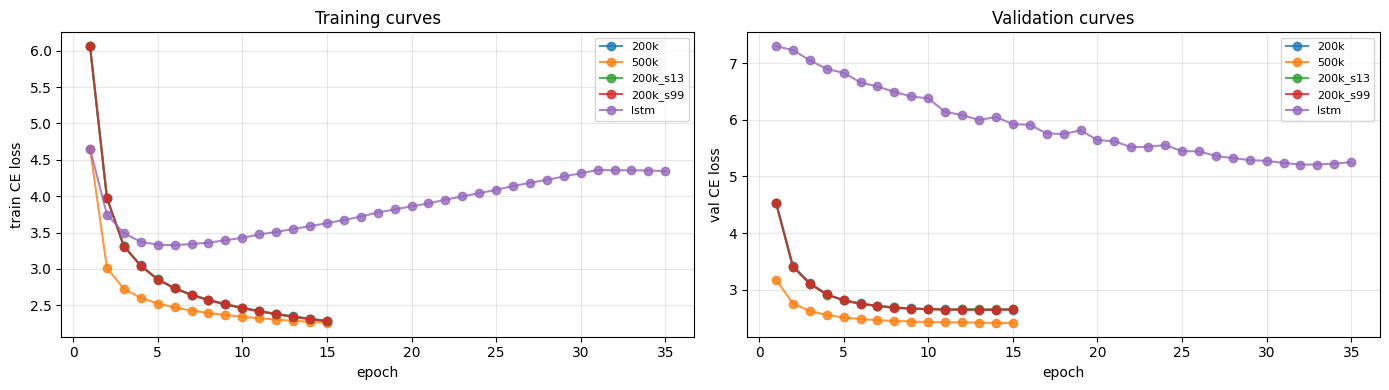

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for rid, m in metrics_dict.items():
    epochs = list(range(1, len(m['val_curve']) + 1))
    axes[0].plot(epochs, m['train_curve'], marker='o', label=rid, alpha=0.8)
    axes[1].plot(epochs, m['val_curve'],   marker='o', label=rid, alpha=0.8)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train CE loss'); axes[0].set_title('Training curves')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val CE loss');   axes[1].set_title('Validation curves')
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('analysis_curves_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

In [42]:
# Multi-seed confidence intervals
seed_runs = {rid: m for rid, m in metrics_dict.items()
             if m['arch'] == 'transformer' and m['config']['max_lines'] == 200_000}

if len(seed_runs) >= 2:
    val_bleus  = np.array([m['val_bleu']  for m in seed_runs.values()])
    test_bleus = np.array([m['test_bleu'] for m in seed_runs.values()])
    seeds      = [m['config']['seed'] for m in seed_runs.values()]
    print(f"Transformer 200k multi-seed (n={len(seed_runs)}, seeds={seeds}):")
    print(f"  Val  BLEU: {val_bleus.mean():.2f} ± {val_bleus.std(ddof=1):.2f}    (min {val_bleus.min():.2f}, max {val_bleus.max():.2f})")
    print(f"  Test BLEU: {test_bleus.mean():.2f} ± {test_bleus.std(ddof=1):.2f}    (min {test_bleus.min():.2f}, max {test_bleus.max():.2f})")
elif len(seed_runs) == 1:
    rid = next(iter(seed_runs))
    print(f"Only 1 Transformer 200k seed loaded ({rid}). Run multi-seed cells in the Transformer notebook for a confidence interval.")
else:
    print('No 200k Transformer runs loaded.')

Transformer 200k multi-seed (n=3, seeds=[42, 13, 99]):
  Val  BLEU: 30.35 ± 0.14    (min 30.22, max 30.49)
  Test BLEU: 30.43 ± 0.23    (min 30.17, max 30.61)


In [43]:
# BLEU bucketed by source length (in words).
LENGTH_BINS = [0, 5, 10, 15, 20, 30, 50, 200]

len_rows = []
for rid in metrics_dict:
    try:
        df = load_run_predictions(rid, 'test', DRIVE_BASE_DIR, DRIVE_OK)
    except FileNotFoundError:
        continue
    df['src_len'] = df['src'].str.split().str.len()
    df['bucket'] = pd.cut(df['src_len'], bins=LENGTH_BINS)
    for bucket, group in df.groupby('bucket', observed=True):
        if len(group) == 0: continue
        bleu = sacrebleu.corpus_bleu(group['hyp'].tolist(), [group['ref'].tolist()]).score
        len_rows.append({'run_id': rid, 'src_len_bucket': str(bucket), 'n': len(group), 'bleu': round(bleu, 2)})

if len_rows:
    length_df = pd.DataFrame(len_rows)
    pivot = length_df.pivot(index='src_len_bucket', columns='run_id', values='bleu')
    print('Test BLEU by source-length bucket (English words):\n')
    print(pivot.to_string())
    pivot.to_csv('analysis_bleu_by_length.csv')
    print('\n(also written to analysis_bleu_by_length.csv)')
else:
    print('No predictions loaded — run a training cell first.')

Test BLEU by source-length bucket (English words):

run_id           200k  200k_s13  200k_s99   500k   lstm
src_len_bucket                                         
(0, 5]          57.61     55.39     55.97  61.79  34.86
(10, 15]        31.05     30.93     31.71  34.24   8.87
(15, 20]        30.38     28.54     29.38  35.26   7.06
(20, 30]        29.57     29.63     29.82  33.94   5.47
(30, 50]        30.59     30.19     30.28  34.33   5.33
(5, 10]         34.41     34.32     35.49  35.77  13.69

(also written to analysis_bleu_by_length.csv)


In [44]:
# Compares LSTM vs Transformer for the architecture-comparison
RUN_A = 'lstm'
RUN_B = '200k'

if RUN_A in metrics_dict and RUN_B in metrics_dict:
    df_a = load_run_predictions(RUN_A, 'test', DRIVE_BASE_DIR, DRIVE_OK)
    df_b = load_run_predictions(RUN_B, 'test', DRIVE_BASE_DIR, DRIVE_OK)
    cmp = df_a.merge(df_b, on=['idx', 'src', 'ref'], suffixes=(f'_{RUN_A}', f'_{RUN_B}'))
    cmp['disagreement'] = (cmp[f'hyp_{RUN_A}'].fillna('').str.len()
                            - cmp[f'hyp_{RUN_B}'].fillna('').str.len()).abs() \
                          + cmp.apply(lambda r: 0 if str(r[f'hyp_{RUN_A}']) == str(r[f'hyp_{RUN_B}']) else 1, axis=1) * 50
    top_diffs = cmp.sort_values('disagreement', ascending=False).head(5)
    print(f"Top-5 sentences where {RUN_A} and {RUN_B} disagree most:\n")
    for _, r in top_diffs.iterrows():
        print(f"EN:  {r['src']}")
        print(f"REF: {r['ref']}")
        print(f"  [{RUN_A}] {r[f'hyp_{RUN_A}']}")
        print(f"  [{RUN_B}] {r[f'hyp_{RUN_B}']}")
        print()
else:
    have = sorted(metrics_dict.keys())
    print(f"Need both {RUN_A} and {RUN_B} loaded. Currently loaded: {have}")

Top-5 sentences where lstm and 200k disagree most:

EN:  however, we must be clear about a number of things: structures in candidate countries vary considerably; in fact they could not vary more, which is why everything we do must be geared to the structures which currently exist in the individual member states.
REF: cependant, certains points méritent quelques éclaircissements : la structure des pays candidats à l'adhésion présente tellement de divergences, il ne pourrait en réalité pas être plus différencié.
  [lstm] il faut structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures structures struc